In [3]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sysstrat.core import Capital, Asset, FixedRiskSizer
from sysstrat.engine import BacktestRunner
from sysstrat.strategies import BuyAndHoldStrategy
from sysstrat.data import load_simple_price_csv

In [8]:
data = load_simple_price_csv("../data/MCFTR.csv")
MCFTR = Asset(ticker= 'MCFTR', price_data=data, commission_rate=0.0004, slippage_rate=0.001)

In [10]:
INITIAL_CAPITAL = 100_000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MAX_LEVERAGE = 1.0

In [12]:
print("🔬 Running Fixed Risk Buy & Hold...")

# 1. Define the Sizer (Handles all the complex risk math)
risk_sizer = FixedRiskSizer(
    volatility_window=VOLATILITY_WINDOW, 
    risk_target=RISK_TARGET, 
    expected_sharpe=10, 
    max_leverage=MAX_LEVERAGE
)

# 2. Define Capital
capital = Capital(initial_capital=INITIAL_CAPITAL)

# 3. Initialize Runner and Run
runner = BacktestRunner(capital=capital, asset=MCFTR, sizer=risk_sizer)
report = runner.run(BuyAndHoldStrategy())

🔬 Running Fixed Risk Buy & Hold...


In [14]:
# Print comprehensive summary (replaces all the manual printing)
report.print_summary()

# Get current position details (if you still want this)
print("=" * 80)
print("CURRENT POSITION DETAILS (End of Period)")
print("=" * 80)

last_pos = report.result.positions.iloc[-1]
last_price = MCFTR.price_data.iloc[-1]
last_lev = report.result.leverage.iloc[-1]

print(f"{'Current Price':30s}: {last_price:,.2f}")
print(f"{'Current Contracts':30s}: {last_pos:,.2f}")
print(f"{'Current Leverage':30s}: {last_lev:.2f}x")


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: Buy and Hold
════════════════════════════════════════════════════════════
 Total Return:        314.95%
 CAGR:                 13.82%
 Annual Volatility:    18.37%
 Sharpe Ratio:          0.75
 Sortino Ratio:        98.32
------------------------------------------------------------
 Max Drawdown:        -49.16%
 Avg Drawdown:         -3.67%
 Win Rate:             53.66%
------------------------------------------------------------
 Skew:                 -0.75
 Kurtosis:              8.17
 Tail Risk:             1.40
------------------------------------------------------------
 Gross PnL:         $325,704.33
 Net PnL:           $314,952.88
 Total Fees:        $ 10,751.45
 Fee Drag Ratio:        0.03
 Cost Efficiency:       0.97
════════════════════════════════════════════════════════════

CURRENT POSITION DETAILS (End of Period)
Current Price                 : 7,470.19
Current Contracts             : 13.00


c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


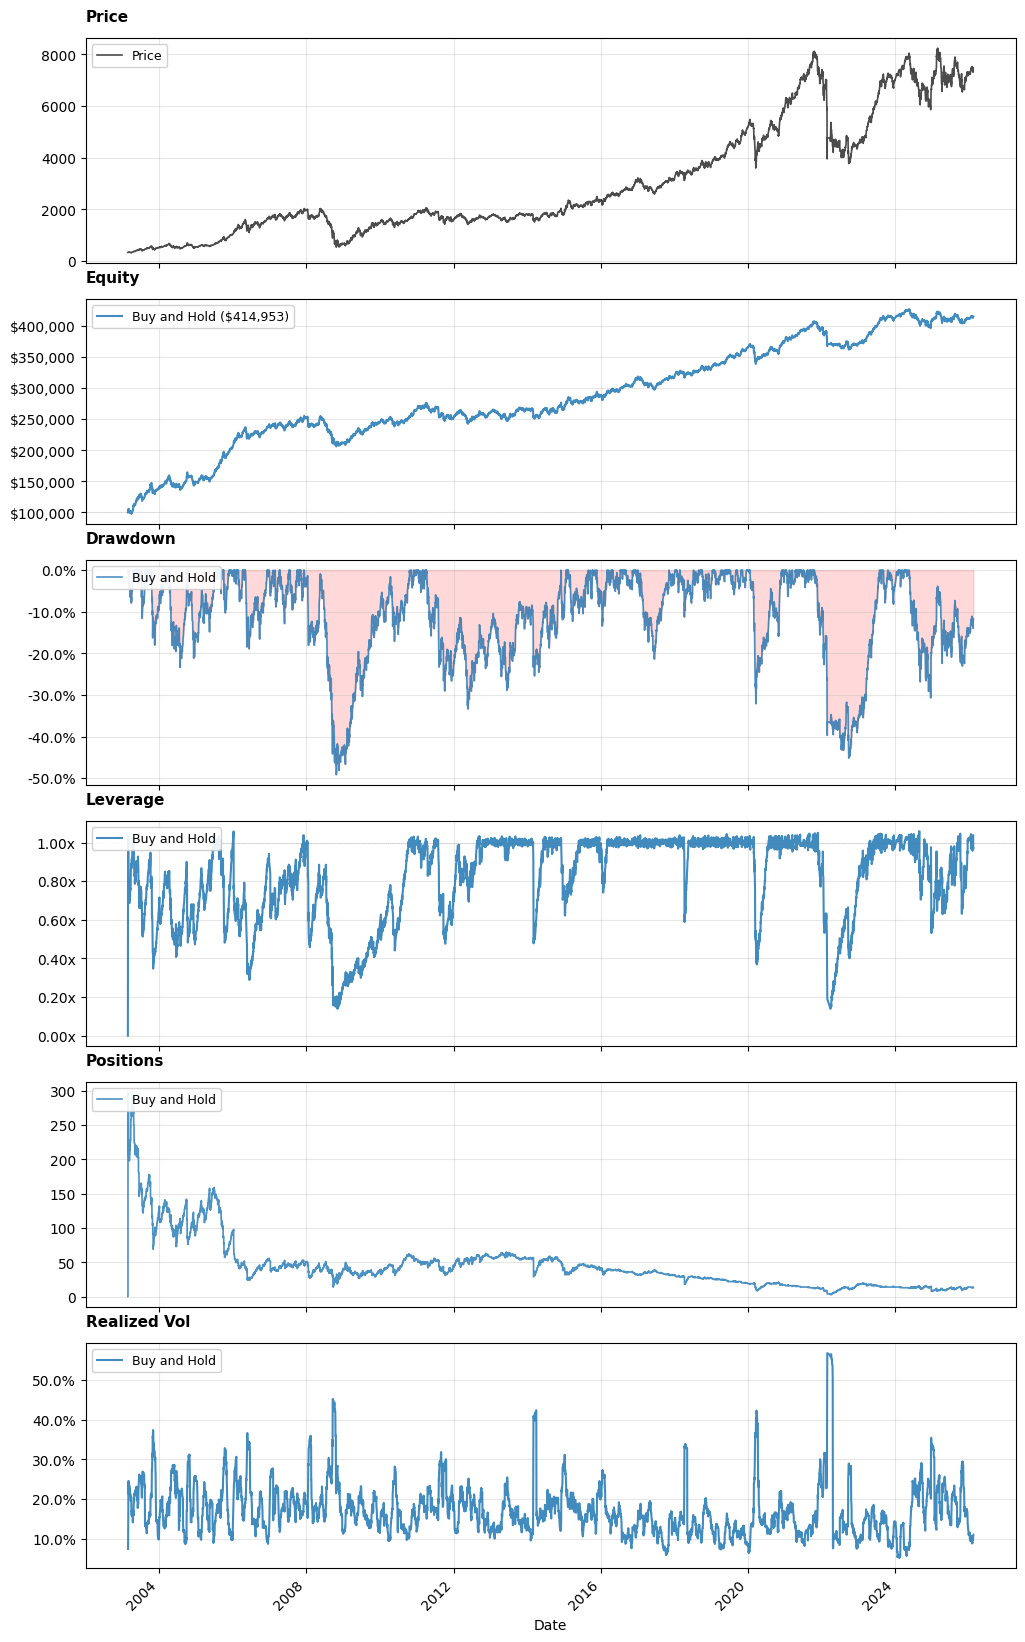

In [15]:
# Plot everything with one line!
report.plot(
    panels=['price', 'equity', 'drawdown', 'leverage', 'positions', 'realized_vol'],
    figsize_base=(12, 3)
)

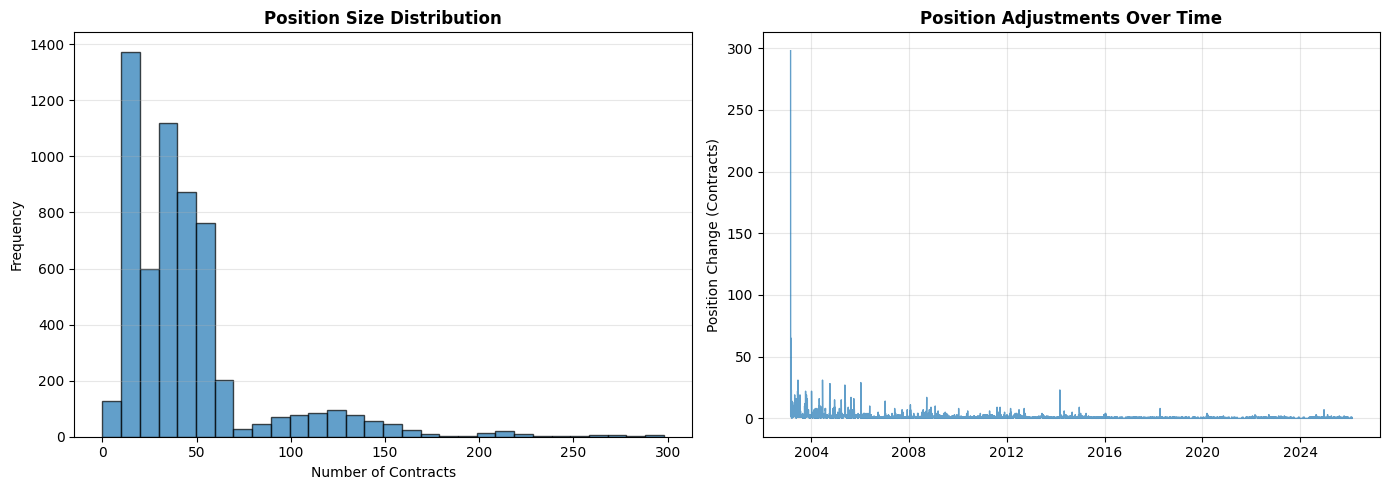

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(report.result.positions.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Contracts')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Position Size Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Time series of position changes
pos_changes = report.result.positions.diff().abs()
axes[1].plot(pos_changes.index, pos_changes, linewidth=1, alpha=0.7)
axes[1].set_ylabel('Position Change (Contracts)')
axes[1].set_title('Position Adjustments Over Time', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()